In [11]:
import pandas as pd

data = pd.read_csv("../data/processed/patient_state_clean.csv")

print("Shape:", data.shape)
data.head()


Shape: (2899, 12)


,SEQN,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Glucose,HbA1c,Insulin,Total_Cholesterol,HDL_Cholesterol,Metabolic_Risk
0,93708.0,66.0,1.0,23.7,141.000000,77.000000,122.0,6.2,9.72,209.0,88.0,1
1,93711.0,56.0,0.0,21.3,101.333333,66.666667,107.0,5.7,5.28,238.0,72.0,1
2,93717.0,22.0,0.0,24.5,118.666667,65.333333,91.0,5.1,3.94,213.0,53.0,0
3,93718.0,45.0,0.0,22.0,131.333333,90.000000,89.0,5.7,4.89,152.0,63.0,1
4,93719.0,13.0,1.0,26.0,101.333333,64.000000,86.0,5.0,10.94,97.0,46.0,0


In [12]:
data = data.drop(columns=["HbA1c"])

In [13]:
FEATURES = [
    "Age", "Gender", "BMI",
    "Systolic_BP", "Diastolic_BP",
    "Glucose", "Insulin",
    "Total_Cholesterol", "HDL_Cholesterol"
]

X = data[FEATURES]
y = data["Metabolic_Risk"]


Train-Test Split

The dataset was split into training (80%) and testing (20%) subsets using stratified sampling 
to preserve the class distribution of the target variable. 
A fixed random_state was used to ensure reproducibility of results.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Feature Scaling

Standardization was applied to continuous features using StandardScaler. 
Scaling was performed after splitting the data to prevent data leakage. 
The scaler was fit on the training data and applied to both training and test sets.


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = log_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))


Logistic Regression Results
Accuracy: 0.755
Precision: 0.713
Recall: 0.658
F1 Score: 0.684


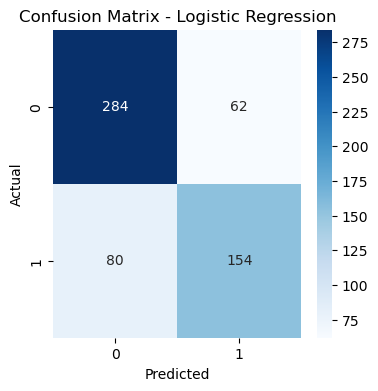

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("confusion_matrix_for_logistic_regression.png", dpi=300)
plt.show()


/var/folders/5w/mdd5s_sd25j0w7pbx4k0l_jc0000gn/T/ipykernel_11827/121251878.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


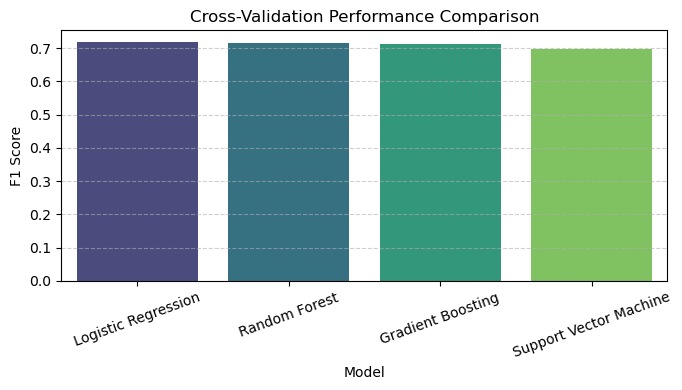

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "Support Vector Machine"
]

f1_scores = [
    0.718,
    0.717,
    0.712,
    0.698
]

plot_df = pd.DataFrame({
    "Model": models,
    "F1 Score": f1_scores
})

plt.figure(figsize=(7,4))

sns.barplot(
    data=plot_df,
    x="Model",
    y="F1 Score",
    palette="viridis"
)

plt.xticks(rotation=20)
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.title("Cross-Validation Performance Comparison")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("model_comparison_new.png", dpi=300, bbox_inches="tight")

plt.show()